<a href="https://colab.research.google.com/github/pedrosouzag/edicao-imagens-ia/blob/main/semana3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install diffusers transformers accelerate torch safetensors -q

In [ ]:
!pip install hf_transfer -q
import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 56.6 MB/s eta 0:00:00


In [ ]:
import torch
from diffusers import StableDiffusionInpaintPipeline, StableDiffusionInstructPix2PixPipeline
from PIL import Image
import matplotlib.pyplot as plt


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Usando:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/constants.py:298: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Usando: cuda


In [ ]:
from huggingface_hub import notebook_login

notebook_login()

inpaint_pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-inpainting",
    torch_dtype=torch.float16).to("cuda")

model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

In [ ]:
image_path = "teste.png"
init_image = Image.open(image_path).convert("RGB").resize((512, 512))

In [ ]:
mask_path = "mascara_ceu_512.png"
mask_image = Image.open(mask_path).convert("RGB").resize((512, 512))
prompt_inpaint = "black sky"

In [ ]:
resultado_inpaint = inpaint_pipe(
    prompt=prompt_inpaint,
    image=init_image,
    mask_image=mask_image,
    num_inference_steps=30,
    guidance_scale=7.5,).images[0]

resultado_inpaint.save("resultado_inpainting.png")

  0%|          | 0/30 [00:00<?, ?it/s]

In [ ]:
pix2pix_pipe = StableDiffusionInstructPix2PixPipeline.from_pretrained(
    "timbrooks/instruct-pix2pix",
    torch_dtype=torch.float16,
).to(device)

instrucao = "black sky"

resultado_pix2pix = pix2pix_pipe(
    instrucao,
    image=init_image,
    num_inference_steps=30,
    image_guidance_scale=1.5,  # quanto preservar a imagem original
    guidance_scale=7.5,        # quanto seguir a instrução de texto
).images[0]

resultado_pix2pix.save("resultado_instructpix2pix.png")

model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

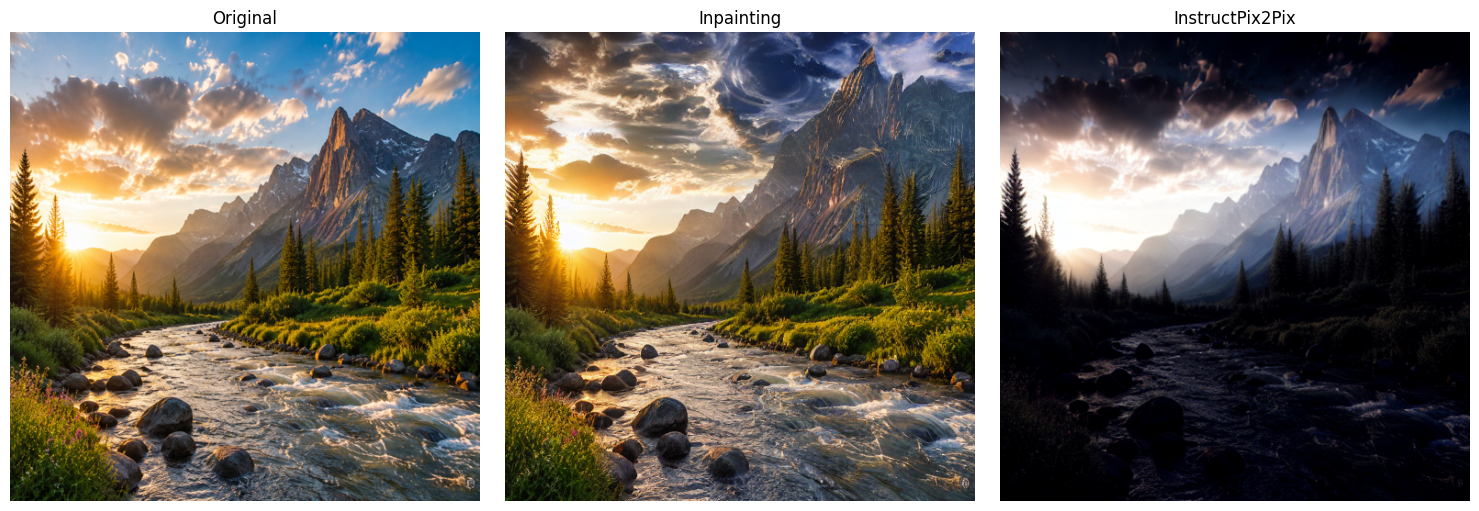

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(init_image)
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(resultado_inpaint)
axs[1].set_title("Inpainting")
axs[1].axis("off")

axs[2].imshow(resultado_pix2pix)
axs[2].set_title("InstructPix2Pix")
axs[2].axis("off")

plt.tight_layout()
plt.savefig("comparacao.png")
plt.show()